# 02 | Evaluation: SHAP vs. LIME vs. IEI on the ENDORISK BN

**Goal.** 
This notebook is used to compute Parimbelli et al. (2023) metrics on the SHAP, LIME and IEI
explanations produced by ImplementationENDORISK.ipynb, aggregated across 5
random seeds.

**Metrics.** 
- Fidelity
- Identity
- Separability
- Execution time

implemented 1:1 from
https://github.com/bmi-labmedinfo/araucana-xai/blob/master/notebooks/araucana_XAI_special_issue.ipynb).

The notebook is structured as follows:

1. Setup: imports, load all per-seed CSVs from output/seed_*/
2. Parimbelli helper functions: get_equal_instances and exp_similarity
3. Per-seed metrics: Fidelity, Identity, Separability and Execution time
4. Aggregate across seeds: mean and std per metric
5. Summary table saved to output/evaluation_summary.csv
6. Figures: one bar chart per metric in output/figures/

## Step 1 — Setup and data loading

In [1]:
import os
import sys
import warnings
import importlib.metadata as _im
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"        : 110,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})


OUTPUT_DIR = "output"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ── Experiment constants (must match ImplementationENDORISK.ipynb cell 2) ────
SEEDS        = [42, 43, 44, 45, 46]
N            = 1000          # explained instances per seed
feature_cols = [
    "PR", "Platelets", "CA125", "Histology", "p53",
    "L1CAM", "ER", "Cytology", "CTMRI",
]

# Method registry
METHODS = ["SHAP", "LIME", "IEI"]
COLORS  = {"SHAP": "#2196F3", "LIME": "#FF9800", "IEI": "#4CAF50"}

print("Setup finished")

Setup finished


In [2]:
# Load seed-specific CSVs into nested dictionaries.

data = {}
for s in SEEDS:
    sd = os.path.join(OUTPUT_DIR, f"seed_{s}")
    df_shap = pd.read_csv(os.path.join(sd, "shap_values.csv"),  index_col="instance_id")
    df_lime = pd.read_csv(os.path.join(sd, "lime_weights.csv"), index_col="instance_id")
    df_iei  = pd.read_csv(os.path.join(sd, "iei_impacts.csv"),  index_col="instance_id")
    df_iei_meta = pd.read_csv(os.path.join(sd, "iei_meta.csv"), index_col="instance_id")
    df_xenc = pd.read_csv(os.path.join(sd, "x_enc_explained.csv"), index_col="instance_id")
    df_time = pd.read_csv(os.path.join(sd, "timing.csv"))

    data[s] = {
        "shap_matrix" : df_shap[feature_cols].values,        # (N, F)
        "lime_matrix" : df_lime[feature_cols].values,
        "iei_matrix"  : df_iei[feature_cols].values,         # Hellinger impacts >= 0
        "iei_meta"    : df_iei_meta,                         # n_e_sig, alpha, theta, conflict_str
        "p_lnm_yes"   : df_shap["P_LNM_yes"].values,
        "local_pred"  : df_lime["local_pred"].values,
        "X_enc"       : df_xenc[feature_cols].astype(int),   # DataFrame, for .duplicated()
        "timing"      : df_time,
    }

# Method registry
METHODS = ["SHAP", "LIME", "IEI"]
COLORS  = {"SHAP": "#2196F3", "LIME": "#FF9800", "IEI": "#4CAF50"}

print(f"Loaded {len(data)} seeds:")
for s in SEEDS:
    d = data[s]
    print(f"  seed {s}: SHAP {d['shap_matrix'].shape}, LIME {d['lime_matrix'].shape}, "
          f"IEI {d['iei_matrix'].shape}, X_enc {d['X_enc'].shape}")


Loaded 5 seeds:
  seed 42: SHAP (1000, 9), LIME (1000, 9), IEI (1000, 9), X_enc (1000, 9)
  seed 43: SHAP (1000, 9), LIME (1000, 9), IEI (1000, 9), X_enc (1000, 9)
  seed 44: SHAP (1000, 9), LIME (1000, 9), IEI (1000, 9), X_enc (1000, 9)
  seed 45: SHAP (1000, 9), LIME (1000, 9), IEI (1000, 9), X_enc (1000, 9)
  seed 46: SHAP (1000, 9), LIME (1000, 9), IEI (1000, 9), X_enc (1000, 9)


## Step 2 — Parimbelli helper functions

Copied from:
https://github.com/bmi-labmedinfo/araucana-xai/blob/master/araucana_AI_special_issue.ipynb

Two small changes to fit this setup: `exp_similarity_shap` is renamed to `exp_similarity` since the same function works for both SHAP and LIME weights, and `feature_cols` replaces Parimbelli's `feature_names`.

In [3]:
# ==== Parimbelli et al. (2023) — copied verbatim from AraucanaXAI =======================
# ========================================================================================
# Source: https://github.com/bmi-labmedinfo/araucana-xai/blob/master/notebooks/araucana_XAI_special_issue.ipynb


# IDENTITY: if there are 2 identical instances, they must have identical explanations
def get_equal_instances(X_test):
    """
    Return all pairs (i, j) of row indices that are duplicates from each other
    
    INPUT:
        X_test (pd.DataFrame): The explained instances, one row per instance.

    OUTPUT:
        dup: list[tuple[int, int]] -> pairs of positional row indices that are exact duplicates. 
            This list will be empty if there are no duplicates. 
        list[tuple[int, int]]: Pairs of **positional** row indices (0-based, as used
            by `.iloc`, not DataFrame index labels) that are exact duplicates.
            Empty list if every row is unique.

    Note:
        Cost of this function is O(k^2) in the number of duplicated rows k, since it checks every 2 combination of flagged rows. 
        Slow, but it does only need to be ran once. 
    
    """
    
    iDup = np.where(X_test.duplicated(keep=False))[0]
    dup = []
    for couple in list(combinations(iDup, 2)):
        check = (X_test.iloc[couple[0]] == X_test.iloc[couple[1]]).all()
        if check:
            dup.append(couple)
    return dup


def exp_similarity(shap_vals_a, shap_vals_b):
    """
    Test whether two explanations rank the features in the same order.

    This is a helper function to compute the IDENTITY metric:
        -> for a pair of identical instances (a, b), their explanations should induce the same feature ranking. 
    
    Each explanation is reduced to the list of feature names sorted by absolute inportance. 
    The 2 lists are compared for exact equality, so it will return a boolean value (true / false)
    
    It compares ALL features values, any reordering counts as a mismatch. 
    

    INPUT:
        shap_vals_a (np.ndarray): Attribution values for instance a. Shape = (9,) 


    OUTPUT:
        int: 1 if both instances have an identical feature ranking, else 0. 

    Note:
        - Relies on the module-level `feature_cols` (feature names in the same order
          as the attribution columns) to label each value.
        - Ties in |value| are broken by Python's stable sort, i.e. by original
          `feature_cols` order — consistent across a and b, so genuinely identical
          attribution arrays always return 1. Deterministic explainers (SHAP, IEI)
          thus score IDENTITY = 1; a stochastic explainer (LIME) can score < 1.
    """
    if len(shap_vals_a.shape) > 1:
        shap_vals_a = shap_vals_a[:, 1]
    z1 = list(zip(feature_cols, abs(shap_vals_a)))
    z1 = sorted(z1, key=lambda x: x[1])
    z1 = [z1[i][0] for i in range(len(z1))]

    if len(shap_vals_b.shape) > 1:
        shap_vals_b = shap_vals_b[:, 1]
    z2 = list(zip(feature_cols, abs(shap_vals_b)))
    z2 = sorted(z2, key=lambda x: x[1])
    z2 = [z2[i][0] for i in range(len(z2))]

    return 1 if z1 == z2 else 0


## Step 3 — Per-seed metric computation

For each of the 5 seeds we compute:

| Metric | SHAP | LIME |
|---|---|---|
| **Fidelity** | `1.0` (Parimbelli convention — global explainer, not a local proxy) | `mean(int(local_pred >= 0.5) == int(P_LNM_yes >= 0.5))` (Parimbelli LIME cell) | 
| **Identity** | rank-order equality across duplicate pairs (`na` if no duplicates) | same metric on LIME weights |
| **Separability** | rank-order equality across non-duplicate pairs (error rate; lower = better). Sub-sampled to 300 instances per seed (44,850 pairs) | same metric on LIME weights |
| **Execution time** | mean seconds/instance from `timing.csv` | mean seconds/instance from `timing.csv` |


In [4]:
# Per-seed metrics for SHAP, LIME and IEI.
# IEI fidelity is N/A: IEI has no local surrogate, so Parimbelli's fidelity metric does not apply.
# Identity and separability work for IEI since its impacts are already >= 0.

SEPARABILITY_SAMPLE = 300

per_seed_metrics: list = []

for s in SEEDS:
    d = data[s]
    print(f"\n==== seed {s} ====")

    # FIDELITY (Parimbelli 2023, Section 3.2)
    
    
    shap_fid = 1.0 # efficiency axiom convention
    lime_pred_class  = (d["local_pred"]  >= 0.5).astype(int)
    model_pred_class = (d["p_lnm_yes"]   >= 0.5).astype(int)
    lime_fid = float(np.mean(lime_pred_class == model_pred_class))
    iei_fid  = float("nan")                              # no surrogate (Kyrimi 2020)
    print(f"  fidelity     : SHAP={shap_fid:.4f}  LIME={lime_fid:.4f}  IEI=N/A")


    # IDENTITY (Parimbelli 2023, Section 3.3)
    
    iDup = np.where(d["X_enc"].duplicated(keep=False))[0]
    dup = []
    for couple in combinations(iDup, 2):
        if (d["X_enc"].iloc[couple[0]].values == d["X_enc"].iloc[couple[1]].values).all():
            dup.append(couple)
    print(f"  duplicates   : {len(dup):,} pairs")

    if len(dup) == 0:
        shap_id = lime_id = iei_id = float("nan")
        print(f"  identity     : N/A (no duplicate pairs)")
    else:
        shap_id = sum(exp_similarity(d["shap_matrix"][a], d["shap_matrix"][b]) for a, b in dup) / len(dup)
        lime_id = sum(exp_similarity(d["lime_matrix"][a], d["lime_matrix"][b]) for a, b in dup) / len(dup)
        iei_id  = sum(exp_similarity(d["iei_matrix"][a],  d["iei_matrix"][b])  for a, b in dup) / len(dup)
        print(f"  identity     : SHAP={shap_id:.4f}  LIME={lime_id:.4f}  IEI={iei_id:.4f}")


    # SEPARABILITY (Parimbelli 2023, Section 3.3)
    
    
    # Sub-sample non-duplicate instances to keep pair count tractable.
    dup_seconds = {pair[1] for pair in dup}
    iNotDup = [i for i in range(N) if i not in dup_seconds]
    rng = np.random.default_rng(s)
    if len(iNotDup) > SEPARABILITY_SAMPLE:
        iNotDup = list(rng.choice(iNotDup, SEPARABILITY_SAMPLE, replace=False))
    combs = list(combinations(iNotDup, 2))

    shap_sep = sum(exp_similarity(d["shap_matrix"][a], d["shap_matrix"][b]) for a, b in combs) / len(combs)
    lime_sep = sum(exp_similarity(d["lime_matrix"][a], d["lime_matrix"][b]) for a, b in combs) / len(combs)
    iei_sep  = sum(exp_similarity(d["iei_matrix"][a],  d["iei_matrix"][b])  for a, b in combs) / len(combs)
    print(f"  separability : SHAP={shap_sep:.6f}  LIME={lime_sep:.6f}  IEI={iei_sep:.6f}  ({len(combs):,} pairs)")

    
    # EXECUTION TIME (El Shawi 2019)
    t = d["timing"].set_index("method")["mean_per_instance_s"]
    shap_time = float(t["SHAP"])
    lime_time = float(t["LIME"])
    iei_time  = float(t["IEI"])
    print(f"  exec time    : SHAP={shap_time:.4f}s  LIME={lime_time:.4f}s  IEI={iei_time:.6f}s")

    
    
    
    # store outputs
    per_seed_metrics.append({
        "seed"             : s,
        "shap_fidelity"    : shap_fid,
        "lime_fidelity"    : lime_fid,
        "iei_fidelity"     : iei_fid,
        "shap_identity"    : shap_id,
        "lime_identity"    : lime_id,
        "iei_identity"     : iei_id,
        "shap_separability": shap_sep,
        "lime_separability": lime_sep,
        "iei_separability" : iei_sep,
        "shap_time_s"      : shap_time,
        "lime_time_s"      : lime_time,
        "iei_time_s"       : iei_time,
        "n_dup_pairs"      : len(dup),
        "n_sep_pairs"      : len(combs),
    })

    
    
# Make a overview table of all data collected. 
df_per_seed = pd.DataFrame(per_seed_metrics).set_index("seed")
df_per_seed.to_csv(os.path.join(OUTPUT_DIR, "per_seed_metrics.csv"))
print("\nPer-seed metrics:")
print(df_per_seed.round(6).to_string())



==== seed 42 ====
  fidelity     : SHAP=1.0000  LIME=0.9310  IEI=N/A


  duplicates   : 60,212 pairs


  identity     : SHAP=1.0000  LIME=0.0110  IEI=1.0000
  separability : SHAP=0.000610  LIME=0.005339  IEI=0.003204  (6,555 pairs)
  exec time    : SHAP=0.3140s  LIME=0.0077s  IEI=0.000590s

==== seed 43 ====
  fidelity     : SHAP=1.0000  LIME=0.9470  IEI=N/A


  duplicates   : 64,878 pairs


  identity     : SHAP=1.0000  LIME=0.0148  IEI=1.0000
  separability : SHAP=0.000420  LIME=0.004342  IEI=0.004202  (7,140 pairs)
  exec time    : SHAP=0.1626s  LIME=0.0083s  IEI=0.000341s

==== seed 44 ====
  fidelity     : SHAP=1.0000  LIME=0.9390  IEI=N/A


...

  identity     : SHAP=1.0000  LIME=0.0135  IEI=1.0000
  separability : SHAP=0.000932  LIME=0.003260  IEI=0.009005  (6,441 pairs)
  exec time    : SHAP=0.3209s  LIME=0.0080s  IEI=0.000264s

==== seed 45 ====
  fidelity     : SHAP=1.0000  LIME=0.9300  IEI=N/A


  duplicates   : 66,055 pairs


  identity     : SHAP=1.0000  LIME=0.0110  IEI=1.0000
  separability : SHAP=0.000621  LIME=0.005123  IEI=0.002174  (6,441 pairs)
  exec time    : SHAP=0.3197s  LIME=0.0082s  IEI=0.000295s

==== seed 46 ====
  fidelity     : SHAP=1.0000  LIME=0.9270  IEI=N/A


  duplicates   : 66,259 pairs


  identity     : SHAP=1.0000  LIME=0.0136  IEI=1.0000
  separability : SHAP=0.000849  LIME=0.003568  IEI=0.005097  (5,886 pairs)
  exec time    : SHAP=0.3334s  LIME=0.0081s  IEI=0.000252s

Per-seed metrics:
      shap_fidelity  lime_fidelity  iei_fidelity  shap_identity  lime_identity  iei_identity  shap_separability  lime_separability  iei_separability  shap_time_s  lime_time_s  iei_time_s  n_dup_pairs  n_sep_pairs
seed                                                                                                                                                                                                                
42              1.0          0.931           NaN            1.0       0.010978           1.0           0.000610           0.005339          0.003204     0.313994     0.007745    0.000590        60212         6555
43              1.0          0.947           NaN            1.0       0.014828           1.0           0.000420           0.004342          0.004202     0

## Step 4 — Aggregate across seeds (mean ± std)

For each metric I report the mean and standard deviation across the 5 seeds. `nanmean` / `nanstd` are used so a seed with no duplicate pairs (e.g. identity on some seeds) doesn't pull the average down.

In [5]:
# Since 5 seeds were used, I will aggregate across all seeds: mean, and std for each method + metric

def agg(col):
    vals = df_per_seed[col].values.astype(float)
    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=0))

agg_rows = []
for label, fmt, direction, cols in [
    ("Fidelity",           ".4f", "higher",
        {"SHAP": "shap_fidelity",     "LIME": "lime_fidelity",     "IEI": "iei_fidelity"}),
    ("Identity",           ".4f", "higher",
        {"SHAP": "shap_identity",     "LIME": "lime_identity",     "IEI": "iei_identity"}),
    ("Separability error", ".6f", "lower",
        {"SHAP": "shap_separability", "LIME": "lime_separability", "IEI": "iei_separability"}),
    ("Exec. time (s/inst)", ".4f", "lower",
        {"SHAP": "shap_time_s",       "LIME": "lime_time_s",       "IEI": "iei_time_s"}),
]:
    row = {
        "Metric": label,
        "Direction": f"^ {direction}" if direction == "higher" else f"v {direction}",
    }
    for method, col in cols.items():
        m, sd = agg(col)
        row[method] = "N/A" if np.isnan(m) else f"{m:{fmt}} ± {sd:{fmt}}"
        row[f"{method}_mean"] = m
        row[f"{method}_std"]  = sd
    agg_rows.append(row)

df_agg = pd.DataFrame(agg_rows).set_index("Metric")
print(df_agg[["Direction", "SHAP", "LIME", "IEI"]].to_string())


                    Direction                 SHAP                 LIME                  IEI
Metric                                                                                      
Fidelity             ^ higher      1.0000 ± 0.0000      0.9348 ± 0.0073                  N/A
Identity             ^ higher      1.0000 ± 0.0000      0.0128 ± 0.0015      1.0000 ± 0.0000
Separability error    v lower  0.000686 ± 0.000183  0.004327 ± 0.000821  0.004736 ± 0.002347
Exec. time (s/inst)   v lower      0.2901 ± 0.0641      0.0081 ± 0.0002      0.0003 ± 0.0001


## Step 5 — Summary table

In [6]:
# Winner per metric across all three methods.
# For metrics with NaN entries (e.g. IEI fidelity), that method is excluded
# from the comparison rather than auto-losing.

def pick_winner_multi(metric, means_dict):
    valid = {m: v for m, v in means_dict.items() if not np.isnan(v)}
    if not valid:
        return "—"
    higher_better = metric in ("Fidelity", "Identity")
    best = max(valid, key=valid.get) if higher_better else min(valid, key=valid.get)
    # Tie detection: if multiple methods tie at the best value
    best_val = valid[best]
    tied = [m for m, v in valid.items() if abs(v - best_val) < 1e-12]
    return "tie" if len(tied) > 1 else best

winners = []
for metric, row in df_agg.iterrows():
    means = {m: row[f"{m}_mean"] for m in METHODS}
    winners.append(pick_winner_multi(metric, means))
df_agg["Winner"] = winners

summary_view = df_agg[["Direction", "SHAP", "LIME", "IEI", "Winner"]]
summary_view.to_csv(os.path.join(OUTPUT_DIR, "evaluation_summary.csv"))
print(summary_view.to_string())


                    Direction                 SHAP                 LIME                  IEI Winner
Metric                                                                                             
Fidelity             ^ higher      1.0000 ± 0.0000      0.9348 ± 0.0073                  N/A   SHAP
Identity             ^ higher      1.0000 ± 0.0000      0.0128 ± 0.0015      1.0000 ± 0.0000    tie
Separability error    v lower  0.000686 ± 0.000183  0.004327 ± 0.000821  0.004736 ± 0.002347   SHAP
Exec. time (s/inst)   v lower      0.2901 ± 0.0641      0.0081 ± 0.0002      0.0003 ± 0.0001    IEI


## Step 6 — Figures

One bar + errorbar plot per metric, saved to `output/figures/`.


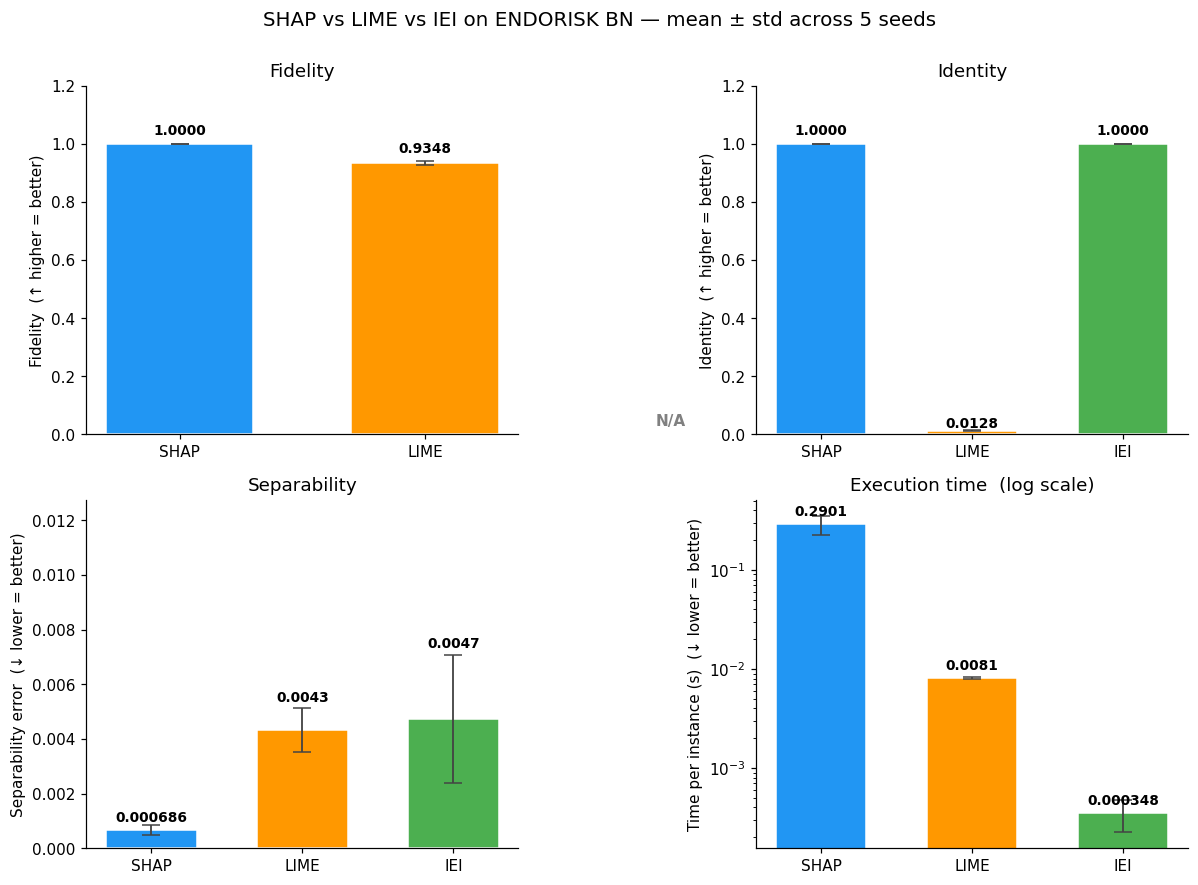

Saved output/figures/metrics_overview.png


In [7]:
# Bar plots: mean ± std across seeds, three methods side-by-side.

def bars3(ax, df_agg_row, ylabel, title, log=False):
    means = [df_agg_row[f"{m}_mean"] for m in METHODS]
    stds  = [df_agg_row[f"{m}_std"]  for m in METHODS]
    colors = [COLORS[m] for m in METHODS]
    bars = ax.bar(METHODS, means, yerr=stds, capsize=6,
                  color=colors, edgecolor="white", width=0.6,
                  error_kw=dict(ecolor="#444", lw=1.2))
    if log:
        ax.set_yscale("log")
    for bar, m_, sd in zip(bars, means, stds):
        if np.isnan(m_):
            ax.text(bar.get_x() + bar.get_width()/2, 0.02, "N/A",
                    ha="center", va="bottom", color="grey", fontweight="bold")
        else:
            offset = m_ * 1.15 if log else (m_ + (sd if not np.isnan(sd) else 0)) * 1.02 + 1e-9
            txt = f"{m_:.4f}" if abs(m_) >= 0.001 else f"{m_:.6f}"
            ax.text(bar.get_x() + bar.get_width()/2, offset, txt,
                    ha="center", va="bottom", fontweight="bold", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(
    f"SHAP vs LIME vs IEI on ENDORISK BN — mean ± std across {len(SEEDS)} seeds",
    y=1.00, fontsize=13,
)

bars3(axes[0, 0], df_agg.loc["Fidelity"],
      "Fidelity  (↑ higher = better)", "Fidelity")
axes[0, 0].set_ylim(0, 1.2)

bars3(axes[0, 1], df_agg.loc["Identity"],
      "Identity  (↑ higher = better)", "Identity")
axes[0, 1].set_ylim(0, 1.2)

r = df_agg.loc["Separability error"]
y_top = max([r[f"{m}_mean"] + (r[f"{m}_std"] or 0) for m in METHODS] + [0.001]) * 1.8
bars3(axes[1, 0], r,
      "Separability error  (↓ lower = better)", "Separability")
axes[1, 0].set_ylim(0, y_top)

bars3(axes[1, 1], df_agg.loc["Exec. time (s/inst)"],
      "Time per instance (s)  (↓ lower = better)",
      "Execution time  (log scale)", log=True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "metrics_overview.png"), bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved {os.path.join(FIG_DIR, 'metrics_overview.png')}")


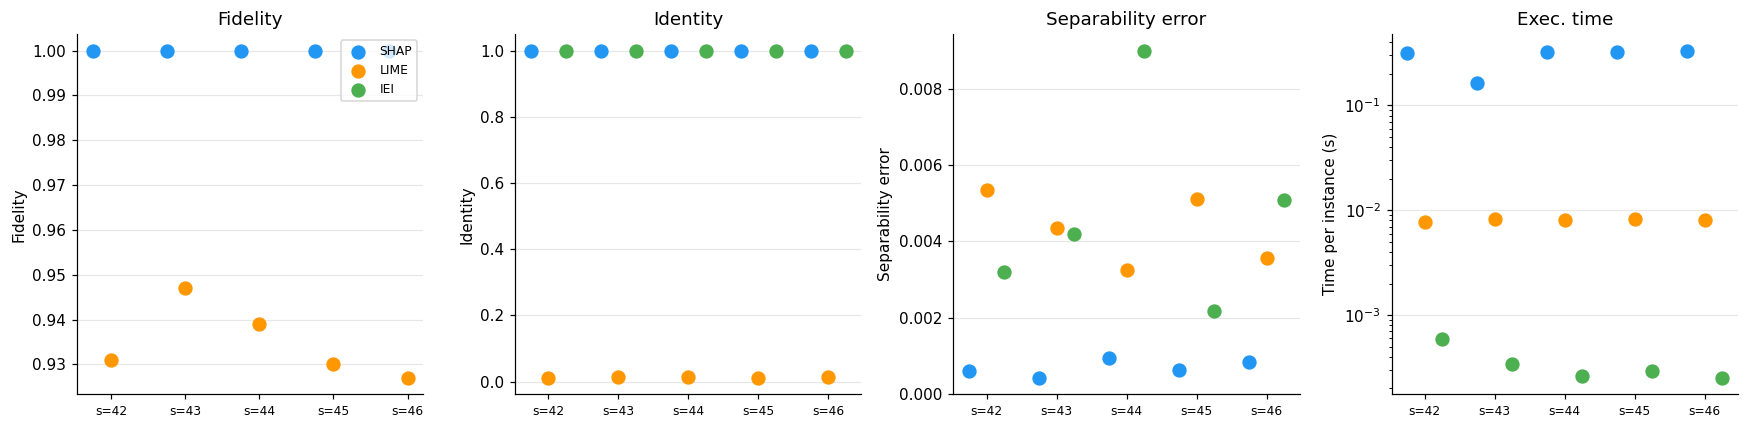

Saved output/figures/per_seed_scatter.png


In [8]:
# Per-seed scatter — shows variance across the 5 seeds for each method.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
panels = [
    ("Fidelity",           "fidelity",     "Fidelity"),
    ("Identity",           "identity",     "Identity"),
    ("Separability error", "separability", "Separability error"),
    ("Exec. time",         "time_s",       "Time per instance (s)"),
]

for ax, (label, suffix, ylabel) in zip(axes, panels):
    x = np.arange(len(SEEDS))
    offsets = {"SHAP": -0.25, "LIME": 0.0, "IEI": 0.25}
    for method in METHODS:
        col = f"{method.lower()}_{suffix}"
        ax.scatter(x + offsets[method], df_per_seed[col],
                   color=COLORS[method], s=70, label=method, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"s={s}" for s in SEEDS], fontsize=8)
    ax.set_title(label)
    ax.set_ylabel(ylabel)
    if label == "Exec. time":
        ax.set_yscale("log")
    ax.grid(True, alpha=0.3, axis="y")

axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "per_seed_scatter.png"), bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved {os.path.join(FIG_DIR, 'per_seed_scatter.png')}")

## Step 7 — IEI-specific analysis

The metrics in Steps 3–5 treat IEI identically to SHAP and LIME so the
comparison is like-for-like. But IEI also produces information that has no
counterpart in SHAP or LIME — the **automatic significance threshold**
(Kyrimi 2020 §4.2.2) and the **conflict category per feature** (Table 1).
This step visualises those.

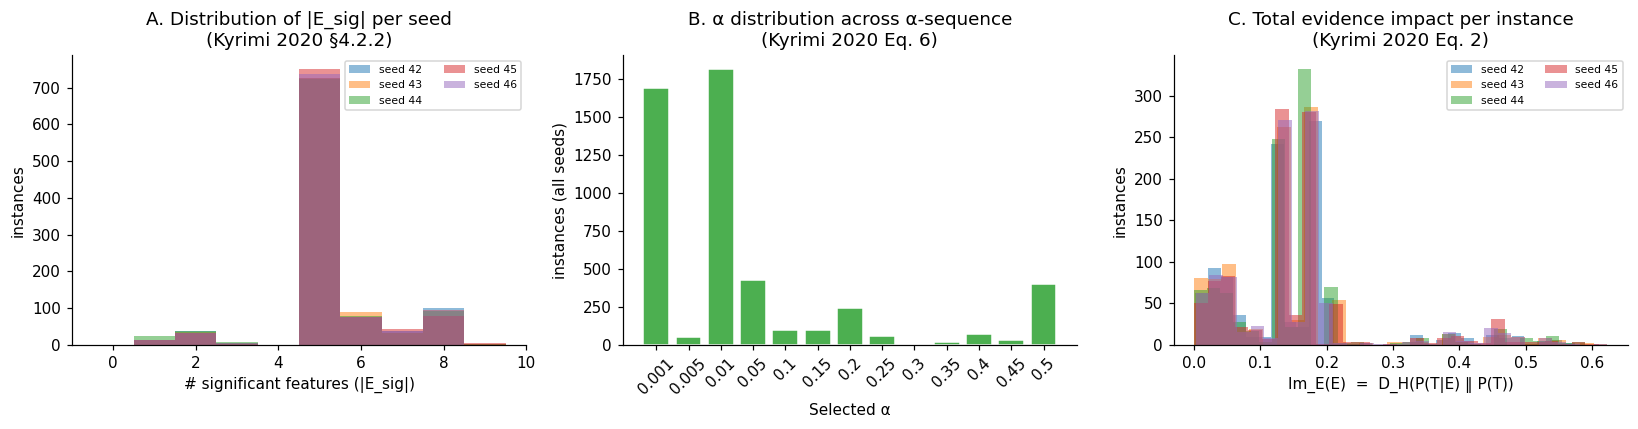

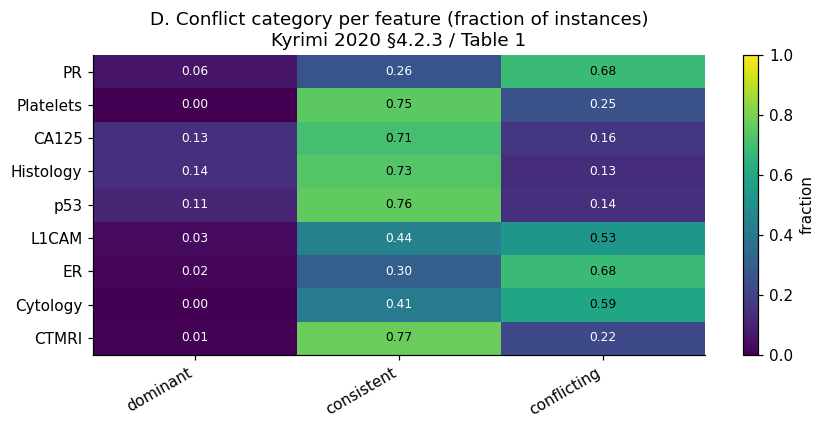

Saved iei_distributions.png, iei_conflict_per_feature.png
Mean |E_sig| : 5.26 / 9
Mean im_E    : 0.1499
Most common α: 0.01


In [9]:
# Aggregate IEI meta across all seeds.
meta_all = pd.concat([data[s]["iei_meta"].assign(seed=s) for s in SEEDS])

# ── Panel A: distribution of n_e_sig per seed ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axA = axes[0]
for s in SEEDS:
    sub = meta_all[meta_all["seed"] == s]["n_e_sig"]
    axA.hist(sub, bins=np.arange(0, len(feature_cols)+2)-0.5,
             alpha=0.5, label=f"seed {s}")
axA.set_xlabel("# significant features (|E_sig|)")
axA.set_ylabel("instances")
axA.set_title("A. Distribution of |E_sig| per seed\n(Kyrimi 2020 §4.2.2)")
axA.legend(fontsize=7, ncol=2)

# ── Panel B: distribution of selected alpha ──────────────────────────────
axB = axes[1]
alpha_counts = meta_all["alpha"].value_counts().sort_index()
axB.bar([f"{a}" for a in alpha_counts.index], alpha_counts.values,
        color="#4CAF50", edgecolor="white")
axB.set_xlabel("Selected α")
axB.set_ylabel("instances (all seeds)")
axB.set_title("B. α distribution across α-sequence\n(Kyrimi 2020 Eq. 6)")
axB.tick_params(axis="x", rotation=45)

# ── Panel C: im_E (total evidence impact) distribution ───────────────────
axC = axes[2]
for s in SEEDS:
    sub = meta_all[meta_all["seed"] == s]["im_E"]
    axC.hist(sub, bins=30, alpha=0.5, label=f"seed {s}")
axC.set_xlabel("Im_E(E)  =  D_H(P(T|E) ‖ P(T))")
axC.set_ylabel("instances")
axC.set_title("C. Total evidence impact per instance\n(Kyrimi 2020 Eq. 2)")
axC.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "iei_distributions.png"), bbox_inches="tight", dpi=140)
plt.show()

# ── Conflict category × feature breakdown ────────────────────────────────
conflict_long = []
for s in SEEDS:
    meta = data[s]["iei_meta"]
    for instance_id, row in meta.iterrows():
        cats = str(row["conflict_str"]).split("|")
        for f_idx, cat in enumerate(cats):
            conflict_long.append({"seed": s, "feature": feature_cols[f_idx], "category": cat})
df_conflict = pd.DataFrame(conflict_long)

pivot = (df_conflict
         .groupby(["feature", "category"]).size()
         .unstack(fill_value=0)
         .reindex(feature_cols))
pivot = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
cat_order = ["dominant", "consistent", "conflicting", "mixed_consistent", "mixed_conflicting"]
cat_order = [c for c in cat_order if c in pivot.columns]
pivot = pivot[cat_order]
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols)
ax.set_xticks(range(len(cat_order)))
ax.set_xticklabels(cat_order, rotation=30, ha="right")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}",
                ha="center", va="center",
                color="white" if pivot.values[i,j] < 0.5 else "black",
                fontsize=8)
ax.set_title("D. Conflict category per feature (fraction of instances)\nKyrimi 2020 §4.2.3 / Table 1")
plt.colorbar(im, ax=ax, label="fraction")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "iei_conflict_per_feature.png"), bbox_inches="tight", dpi=140)
plt.show()

pivot.round(4).to_csv(os.path.join(OUTPUT_DIR, "iei_conflict_per_feature.csv"))
print(f"Saved iei_distributions.png, iei_conflict_per_feature.png")
print(f"Mean |E_sig| : {meta_all['n_e_sig'].mean():.2f} / {len(feature_cols)}")
print(f"Mean im_E    : {meta_all['im_E'].mean():.4f}")
print(f"Most common α: {meta_all['alpha'].mode().iloc[0]}")

## Step 8 — Cross-method disagreement (SHAP vs LIME vs IEI)

The Parimbelli metrics compare each explainer against itself, or to the model. They do not tell us whether SHAP, LIME and IEI agree with **each other** about which features matter.

In this part I will cover the disagreement problem. 

**Krishna et al. (2022). The Disagreement Problem in Explainable Machine Learning: A Practitioner's Perspective. **

Krishna et al. define multiple agreement metrics, these are 2 I will cover:

1. **Global feature ranking agreement (Spearman ρ).**
   For each seed, build one global importance per feature per method using
   'mean(|score|)' across the 1,000 instances. Rank the 9 features under each
   method and compute Spearman ρ between every method pair. Reported as
   mean ± std across the 5 seeds.

   IEI's Hellinger impacts are already non-negative (Kyrimi 2020 Eq. 1), so
   the '|·|' for SHAP and LIME makes the three sides directly comparable.

2. **Per-instance ranking agreement.**
   For each instance, compute Spearman ρ between every method-pair's rank
   vector. Report distribution (mean, std, p5, p95) over the 5,000 instances.


Global feature ranking agreement (Spearman ρ per seed):
      SHAP_vs_LIME  SHAP_vs_IEI  LIME_vs_IEI
seed                                        
42          0.8167       0.9500       0.6333
43          0.8000       0.9333       0.6333
44          0.7333       0.9833       0.6333
45          0.7167       0.9667       0.6333
46          0.7167       0.9167       0.5833

Mean ± std across seeds:
  SHAP_vs_LIME        +0.7567 ± 0.0429
  SHAP_vs_IEI         +0.9500 ± 0.0236
  LIME_vs_IEI         +0.6233 ± 0.0200



Per-instance ranking agreement (Spearman ρ across 5×N instances):
                 n    mean     std      p5   p50     p95
pair                                                    
SHAP_vs_LIME  5000  0.5793  0.2056  0.2000  0.60  0.8667
SHAP_vs_IEI   5000  0.7738  0.1362  0.5333  0.80  0.9500
LIME_vs_IEI   5000  0.5724  0.2558  0.0667  0.65  0.8667


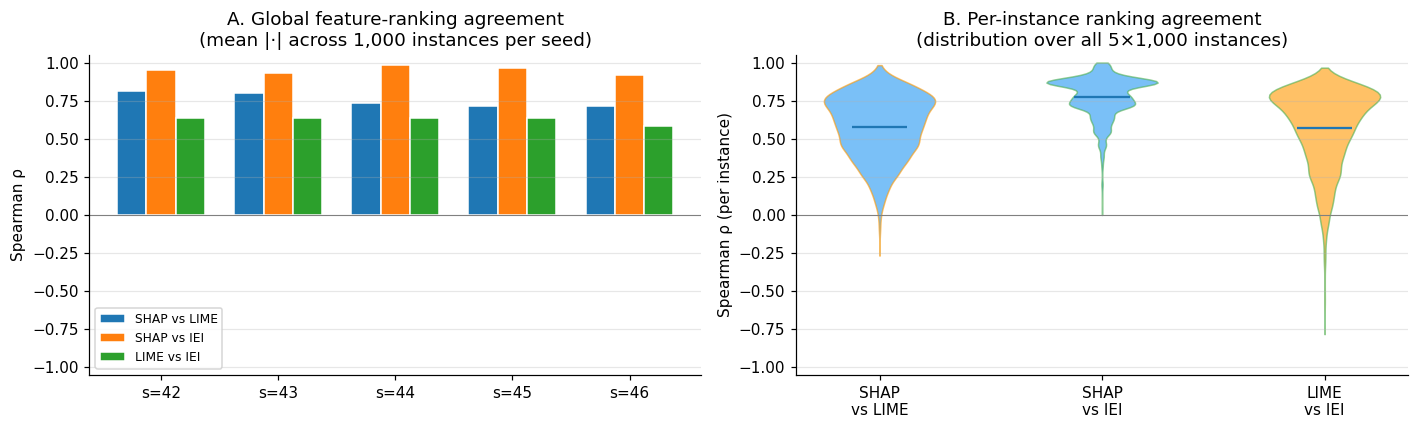

Saved disagreement.png


In [10]:
from scipy.stats import spearmanr

pairs = [("SHAP", "LIME"), ("SHAP", "IEI"), ("LIME", "IEI")]
global_rho_rows = []

for s in SEEDS:
    d = data[s]
    g = {
        "SHAP": np.abs(d["shap_matrix"]).mean(axis=0),
        "LIME": np.abs(d["lime_matrix"]).mean(axis=0),
        "IEI":  d["iei_matrix"].mean(axis=0),
    }
    row = {"seed": s}
    for a, b in pairs:
        rho, _ = spearmanr(g[a], g[b])
        row[f"{a}_vs_{b}"] = rho
    global_rho_rows.append(row)

df_global = pd.DataFrame(global_rho_rows).set_index("seed")
print("Global feature ranking agreement (Spearman ρ per seed):")
print(df_global.round(4).to_string())
print("\nMean ± std across seeds:")
for col in df_global.columns:
    vals = df_global[col].values
    print(f"  {col:18s}  {vals.mean():+.4f} ± {vals.std(ddof=0):.4f}")
df_global.to_csv(os.path.join(OUTPUT_DIR, "disagreement_global.csv"))

# ── Per-instance ranking agreement ───────────────────────────────────────
per_inst_rho = {f"{a}_vs_{b}": [] for a, b in pairs}
for s in SEEDS:
    d = data[s]
    M = {
        "SHAP": np.abs(d["shap_matrix"]),
        "LIME": np.abs(d["lime_matrix"]),
        "IEI":  d["iei_matrix"],
    }
    for i in range(M["SHAP"].shape[0]):
        for a, b in pairs:
            va, vb = M[a][i], M[b][i]
            if np.all(va == va[0]) or np.all(vb == vb[0]):
                continue
            rho, _ = spearmanr(va, vb)
            if not np.isnan(rho):
                per_inst_rho[f"{a}_vs_{b}"].append(rho)

rows = []
for k, vs in per_inst_rho.items():
    arr = np.array(vs)
    rows.append({"pair": k, "n": len(arr), "mean": arr.mean(),
                 "std": arr.std(ddof=0), "p5": np.percentile(arr, 5),
                 "p50": np.percentile(arr, 50), "p95": np.percentile(arr, 95)})
df_inst = pd.DataFrame(rows).set_index("pair")
print("\nPer-instance ranking agreement (Spearman ρ across 5×N instances):")
print(df_inst.round(4).to_string())
df_inst.to_csv(os.path.join(OUTPUT_DIR, "disagreement_per_instance.csv"))

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axA = axes[0]
x = np.arange(len(SEEDS))
width = 0.25
for i, (a, b) in enumerate(pairs):
    axA.bar(x + (i - 1) * width, df_global[f"{a}_vs_{b}"].values, width,
            label=f"{a} vs {b}", edgecolor="white")
axA.axhline(0, color="grey", lw=0.7)
axA.set_xticks(x)
axA.set_xticklabels([f"s={s}" for s in SEEDS])
axA.set_ylabel("Spearman ρ")
axA.set_title("A. Global feature-ranking agreement\n(mean |·| across 1,000 instances per seed)")
axA.set_ylim(-1.05, 1.05)
axA.legend(fontsize=8)
axA.grid(True, axis="y", alpha=0.3)

axB = axes[1]
positions = list(range(len(pairs)))
vp = axB.violinplot([per_inst_rho[f"{a}_vs_{b}"] for a, b in pairs],
                    positions=positions, showmeans=True, showextrema=False)
for body, (a, b) in zip(vp["bodies"], pairs):
    body.set_facecolor(COLORS[a])
    body.set_edgecolor(COLORS[b])
    body.set_alpha(0.6)
axB.set_xticks(positions)
axB.set_xticklabels([f"{a}\nvs {b}" for a, b in pairs])
axB.axhline(0, color="grey", lw=0.7)
axB.set_ylabel("Spearman ρ (per instance)")
axB.set_title("B. Per-instance ranking agreement\n(distribution over all 5×1,000 instances)")
axB.set_ylim(-1.05, 1.05)
axB.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "disagreement.png"), bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved disagreement.png")

## Step 9 — Stability (within-class explanation coherence)

Measures whether instances with the same model-predicted class receive
similar explanations. Design follows El Shawi et al. (2019): within each
predicted class (LNM yes / no), draw random pairs and score them with
Parimbelli's `exp_similarity`. Stability = fraction of pairs that match,
averaged across classes.

Per-seed within-class stability:
      shap_stability  lime_stability  iei_stability
seed                                               
42             0.095           0.007          0.096
43             0.118           0.009          0.090
44             0.119           0.005          0.107
45             0.123           0.001          0.104
46             0.140           0.009          0.132

Mean ± std across seeds:
  shap_stability      0.1190 ± 0.0144
  lime_stability      0.0062 ± 0.0030
  iei_stability       0.1058 ± 0.0144


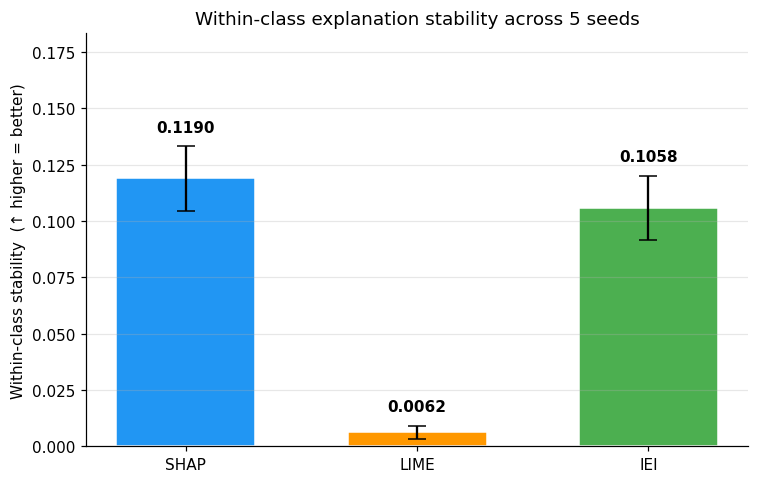

Saved stability.png


In [11]:
STABILITY_SAMPLE = 500   # random pairs per (class, method, seed)
stability_rows = []

for s in SEEDS:
    d = data[s]
    y = (d["p_lnm_yes"] >= 0.5).astype(int)
    rng = np.random.default_rng(s + 200)

    matrices = {"SHAP": d["shap_matrix"], "LIME": d["lime_matrix"], "IEI": d["iei_matrix"]}
    row = {"seed": s}
    for method, M in matrices.items():
        scores_per_class = []
        for cls in [0, 1]:
            idx = np.where(y == cls)[0]
            if len(idx) < 2:
                continue
            n_pairs = min(STABILITY_SAMPLE, len(idx) * (len(idx) - 1) // 2)
            pair_ids = set()
            attempts = 0
            while len(pair_ids) < n_pairs and attempts < n_pairs * 10:
                a, b = rng.choice(idx, 2, replace=False)
                pair_ids.add((min(a, b), max(a, b)))
                attempts += 1
            sims = [exp_similarity(M[a], M[b]) for a, b in pair_ids]
            scores_per_class.append(np.mean(sims) if sims else np.nan)
        row[f"{method.lower()}_stability"] = float(np.nanmean(scores_per_class))
    stability_rows.append(row)

df_stab = pd.DataFrame(stability_rows).set_index("seed")
df_stab.to_csv(os.path.join(OUTPUT_DIR, "stability.csv"))
print("Per-seed within-class stability:")
print(df_stab.round(4).to_string())
print("\nMean ± std across seeds:")
for col in df_stab.columns:
    vals = df_stab[col].values
    print(f"  {col:18s}  {vals.mean():.4f} ± {vals.std(ddof=0):.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
methods_lc = [m.lower() for m in METHODS]
means = [df_stab[f"{m}_stability"].mean() for m in methods_lc]
stds  = [df_stab[f"{m}_stability"].std(ddof=0) for m in methods_lc]
bars = ax.bar(METHODS, means, yerr=stds, capsize=6,
              color=[COLORS[m] for m in METHODS], edgecolor="white", width=0.6)
for bar, m_, sd in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m_ + sd + 0.005,
            f"{m_:.4f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Within-class stability  (↑ higher = better)")
ax.set_title(f"Within-class explanation stability across {len(SEEDS)} seeds")
ax.set_ylim(0, max(max(means) + max(stds) + 0.05, 0.1))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "stability.png"), bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved stability.png")

## Step 10 — Top-k feature agreement (tab:topk in thesis)

How often do SHAP, LIME and IEI agree on the single most important feature
(top-1) and how much do their top-5 sets overlap? Computed over all
5 × 1,000 instances.

In [12]:
pairs_topk = [("SHAP", "LIME"), ("SHAP", "IEI"), ("LIME", "IEI")]

top1       = {f"{a}_{b}": [] for a, b in pairs_topk}
top5_isect = {f"{a}_{b}": [] for a, b in pairs_topk}
all_three_top1 = []

for s in SEEDS:
    d = data[s]
    M = {
        "SHAP": np.abs(d["shap_matrix"]),
        "LIME": np.abs(d["lime_matrix"]),
        "IEI":  d["iei_matrix"],
    }
    n_inst = M["SHAP"].shape[0]
    for i in range(n_inst):
        ranks = {m: np.argsort(-M[m][i]) for m in M}
        for a, b in pairs_topk:
            top1[f"{a}_{b}"].append(int(ranks[a][0] == ranks[b][0]))
            top5_isect[f"{a}_{b}"].append(len(set(ranks[a][:5]) & set(ranks[b][:5])))
        all_three_top1.append(
            int(ranks["SHAP"][0] == ranks["LIME"][0] == ranks["IEI"][0]))

rows_topk = []
for a, b in pairs_topk:
    key = f"{a}_{b}"
    rows_topk.append({
        "pair":              key,
        "top1_agreement":    round(np.mean(top1[key]), 4),
        "top5_jaccard":      round(np.mean(top5_isect[key]) / 5, 4),
        "top5_intersection": round(np.mean(top5_isect[key]), 4),
    })

df_topk = pd.DataFrame(rows_topk).set_index("pair")
df_topk.to_csv(os.path.join(OUTPUT_DIR, "topk_agreement.csv"))
print("Top-k feature agreement:")
print(df_topk.round(4).to_string())
print(f"\nAll-three top-1 agreement: {np.mean(all_three_top1):.4f}")

Top-k feature agreement:
           top1_agreement  top5_jaccard  top5_intersection
pair                                                      
SHAP_LIME          0.4772        0.7286             3.6432
SHAP_IEI           0.8462        0.7967             3.9834
LIME_IEI           0.5330        0.7205             3.6024

All-three top-1 agreement: 0.4332


## Step 11 — Instance explanation figures

Generates `instance_explanation_panel.png` (instance 19 explained by all
three methods) and `instance_flip_comparison.png` (counterfactual flip of
Histology grade_3 → grade_2, instances 19 and 130). Saves to
`output/figures/`.

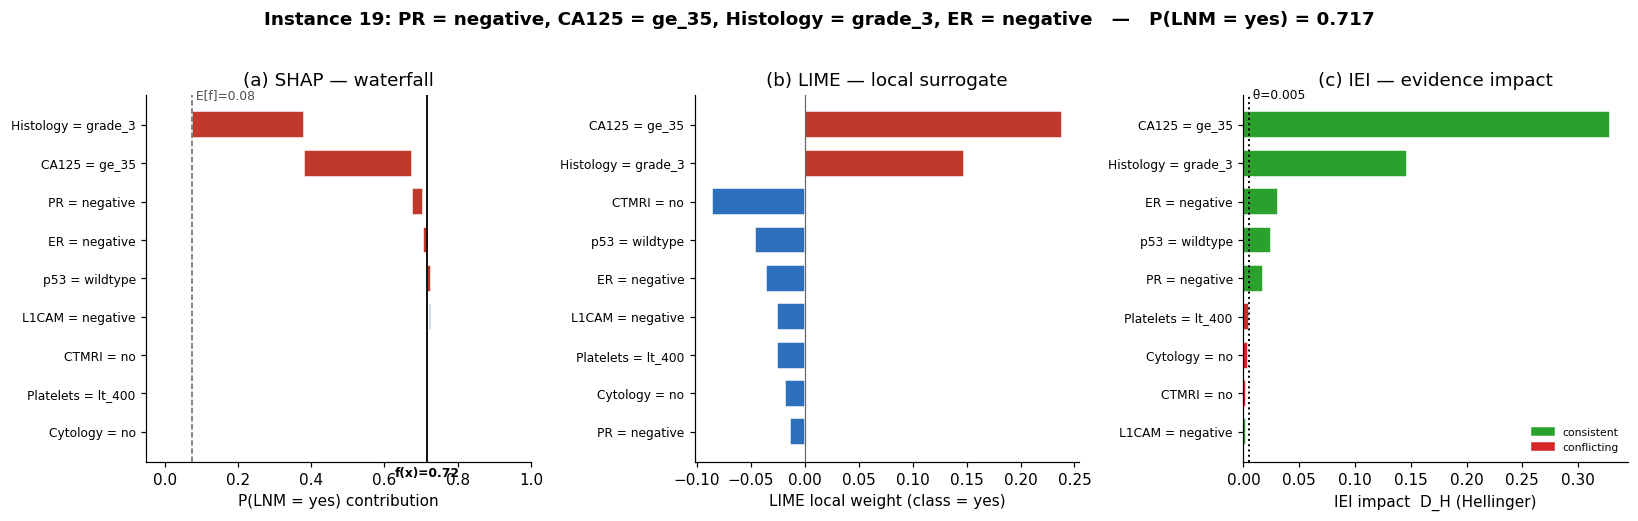

Saved instance_explanation_panel.png


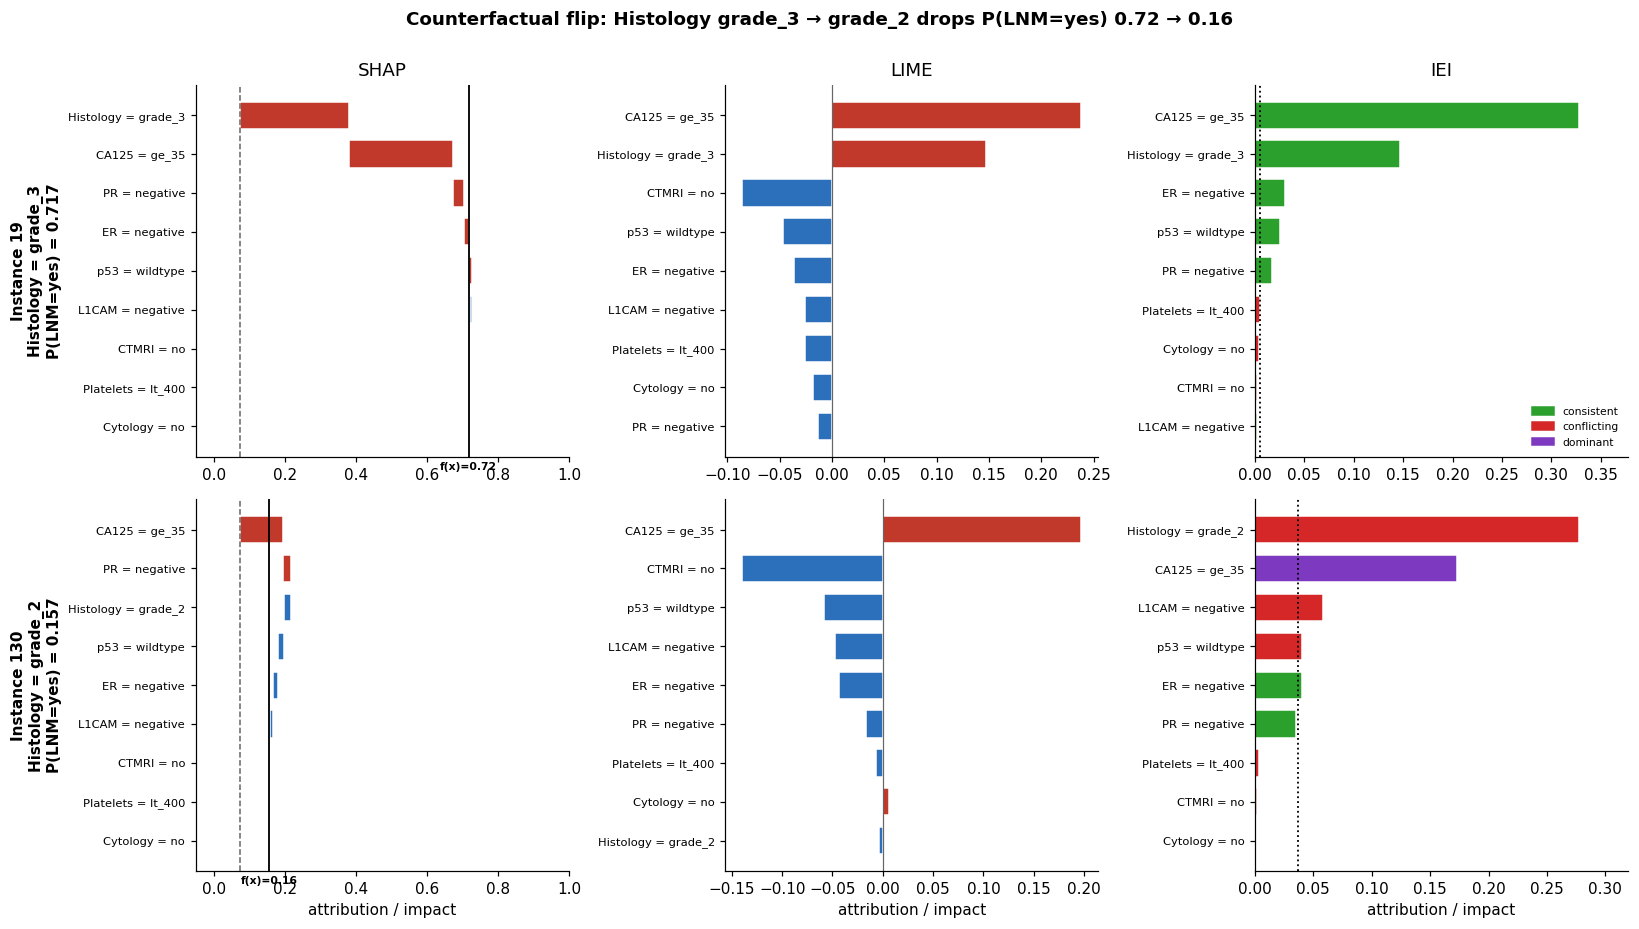

Saved instance_flip_comparison.png


In [13]:
from pgmpy.readwrite import BIFReader
from matplotlib.patches import Patch

SEED_INST = 42
SD = os.path.join(OUTPUT_DIR, f"seed_{SEED_INST}")
FEATS = feature_cols

shap_df = pd.read_csv(os.path.join(SD, "shap_values.csv"),      index_col="instance_id")
lime_df = pd.read_csv(os.path.join(SD, "lime_weights.csv"),     index_col="instance_id")
iei_df  = pd.read_csv(os.path.join(SD, "iei_impacts.csv"),      index_col="instance_id")
meta_df = pd.read_csv(os.path.join(SD, "iei_meta.csv"),         index_col="instance_id")
xe_df   = pd.read_csv(os.path.join(SD, "x_enc_explained.csv"),  index_col="instance_id")
BASE    = float(pd.read_csv(os.path.join(SD, "shap_base_value.csv")).iloc[0, 0])

bif_model = BIFReader("Endorisk/endomcancer.bif").get_model()
DECODE    = {v: bif_model.get_cpds(v).state_names[v] for v in FEATS}

INST_A = 19
INST_B = 130

POS = "#c0392b"
NEG = "#2c6fbb"
CONFLICT_COLORS = {
    "consistent":       "#2ca02c",
    "conflicting":      "#d62728",
    "dominant":         "#7d3ac1",
    "mixed_consistent": "#8c8c8c",
    "mixed_conflicting":"#bdbdbd",
}

def inst_label(iid):
    return [f"{v} = {DECODE[v][int(xe_df.loc[iid, v])]}" for v in FEATS]

def inst_conflict_map(iid):
    cs = str(meta_df.loc[iid, "conflict_str"]).split("|")
    return dict(zip(FEATS, cs))

def waterfall_bars(ax, vals, ypos, base):
    cum = base
    for y, v in zip(ypos, vals):
        ax.barh(y, v, left=cum, color=POS if v >= 0 else NEG,
                edgecolor="white", height=0.7)
        cum += v

def panel_shap(ax, iid):
    vals  = shap_df.loc[iid, FEATS].values.astype(float)
    pred  = float(shap_df.loc[iid, "P_LNM_yes"])
    order = np.argsort(np.abs(vals))[::-1]
    ypos  = np.arange(len(order))[::-1]
    waterfall_bars(ax, vals[order], ypos, BASE)
    ax.axvline(BASE, color="0.4", ls="--", lw=1)
    ax.text(BASE, len(order) - 0.3, f" E[f]={BASE:.2f}", color="0.3", fontsize=8)
    ax.axvline(pred, color="black", ls="-", lw=1.2)
    ax.text(pred, -0.9, f"f(x)={pred:.2f}", fontsize=8, ha="center", va="top", fontweight="bold")
    ax.set_yticks(ypos)
    ax.set_yticklabels([inst_label(iid)[i] for i in order], fontsize=8)
    ax.set_xlabel("P(LNM = yes) contribution")
    ax.set_title("(a) SHAP — waterfall")
    ax.set_xlim(-0.05, 1.0)

def panel_lime(ax, iid):
    vals  = lime_df.loc[iid, FEATS].values.astype(float)
    order = np.argsort(np.abs(vals))[::-1]
    ypos  = np.arange(len(order))[::-1]
    ax.barh(ypos, vals[order],
            color=[POS if v >= 0 else NEG for v in vals[order]],
            edgecolor="white", height=0.7)
    ax.axvline(0, color="0.4", lw=0.8)
    ax.set_yticks(ypos)
    ax.set_yticklabels([inst_label(iid)[i] for i in order], fontsize=8)
    ax.set_xlabel("LIME local weight (class = yes)")
    ax.set_title("(b) LIME — local surrogate")

def panel_iei(ax, iid):
    vals  = iei_df.loc[iid, FEATS].values.astype(float)
    cmap  = inst_conflict_map(iid)
    theta = float(meta_df.loc[iid, "theta"])
    order = np.argsort(vals)[::-1]
    ypos  = np.arange(len(order))[::-1]
    ax.barh(ypos, vals[order],
            color=[CONFLICT_COLORS.get(cmap[FEATS[i]], "0.6") for i in order],
            edgecolor="white", height=0.7)
    ax.axvline(theta, color="black", ls=":", lw=1.3)
    ax.text(theta, len(order) - 0.3, f" θ={theta:.3f}", fontsize=8)
    ax.set_yticks(ypos)
    ax.set_yticklabels([inst_label(iid)[i] for i in order], fontsize=8)
    ax.set_xlabel("IEI impact  D_H (Hellinger)")
    ax.set_title("(c) IEI — evidence impact")
    present = [c for c in CONFLICT_COLORS if c in cmap.values()]
    ax.legend(handles=[Patch(color=CONFLICT_COLORS[c], label=c) for c in present],
              fontsize=7, loc="lower right", frameon=False)

# ── Figure A: anatomy of one explanation ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
pred_A = float(shap_df.loc[INST_A, "P_LNM_yes"])
panel_shap(axes[0], INST_A)
panel_lime(axes[1], INST_A)
panel_iei(axes[2], INST_A)
profile     = {v: DECODE[v][int(xe_df.loc[INST_A, v])] for v in FEATS}
non_default = [f"{v} = {s}" for v, s in profile.items() if int(xe_df.loc[INST_A, v]) != 0]
fig.suptitle(
    f"Instance {INST_A}: {', '.join(non_default)}   —   P(LNM = yes) = {pred_A:.3f}",
    fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "instance_explanation_panel.png"), bbox_inches="tight")
plt.show()
print(f"Saved instance_explanation_panel.png")

# ── Figure B: counterfactual flip ────────────────────────────────────────
def flip_row(axes, iid):
    pred = float(shap_df.loc[iid, "P_LNM_yes"])
    v = shap_df.loc[iid, FEATS].values.astype(float)
    o = np.argsort(np.abs(v))[::-1]
    yp = np.arange(len(o))[::-1]
    waterfall_bars(axes[0], v[o], yp, BASE)
    axes[0].axvline(BASE, color="0.4", ls="--", lw=1)
    axes[0].axvline(pred, color="black", ls="-", lw=1.2)
    axes[0].text(pred, -0.9, f"f(x)={pred:.2f}", fontsize=7, ha="center", va="top", fontweight="bold")
    axes[0].set_yticks(yp); axes[0].set_yticklabels([inst_label(iid)[i] for i in o], fontsize=7.5)
    axes[0].set_xlim(-0.05, 1.0)

    v = lime_df.loc[iid, FEATS].values.astype(float)
    o = np.argsort(np.abs(v))[::-1]; yp = np.arange(len(o))[::-1]
    axes[1].barh(yp, v[o], color=[POS if x >= 0 else NEG for x in v[o]], edgecolor="white", height=0.7)
    axes[1].axvline(0, color="0.4", lw=0.8)
    axes[1].set_yticks(yp); axes[1].set_yticklabels([inst_label(iid)[i] for i in o], fontsize=7.5)

    v = iei_df.loc[iid, FEATS].values.astype(float)
    cmap  = inst_conflict_map(iid); theta = float(meta_df.loc[iid, "theta"])
    o = np.argsort(v)[::-1]; yp = np.arange(len(o))[::-1]
    axes[2].barh(yp, v[o], color=[CONFLICT_COLORS.get(cmap[FEATS[i]], "0.6") for i in o],
                 edgecolor="white", height=0.7)
    axes[2].axvline(theta, color="black", ls=":", lw=1.2)
    axes[2].set_yticks(yp); axes[2].set_yticklabels([inst_label(iid)[i] for i in o], fontsize=7.5)
    axes[2].set_xlim(0, max(0.05, v.max() * 1.15))
    return pred

fig, axes = plt.subplots(2, 3, figsize=(15, 8.4))
pa = flip_row(axes[0], INST_A)
pb = flip_row(axes[1], INST_B)
axes[0][0].set_title("SHAP"); axes[0][1].set_title("LIME"); axes[0][2].set_title("IEI")
axes[0][0].set_ylabel(f"Instance {INST_A}\nHistology = grade_3\nP(LNM=yes) = {pa:.3f}",
                       fontsize=10, fontweight="bold")
axes[1][0].set_ylabel(f"Instance {INST_B}\nHistology = grade_2\nP(LNM=yes) = {pb:.3f}",
                       fontsize=10, fontweight="bold")
for ax in axes[1]: ax.set_xlabel("attribution / impact")
present = ["consistent", "conflicting", "dominant"]
axes[0][2].legend(handles=[Patch(color=CONFLICT_COLORS[c], label=c) for c in present],
                  fontsize=7, loc="lower right", frameon=False)
fig.suptitle(
    f"Counterfactual flip: Histology grade_3 → grade_2 drops P(LNM=yes) {pa:.2f} → {pb:.2f}",
    fontsize=12, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "instance_flip_comparison.png"), bbox_inches="tight")
plt.show()
print(f"Saved instance_flip_comparison.png")